# Trabajo Final

Prueba "Tablero de seguimiento de cuba con problemas de balance térmico"

Para ello vamos a monitorear los últimos 3 meses de la cuba 626.


In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [162]:
# Cargamos el dataset (Ejemplo Sala 5 - ultimos 3 meses)
df = pd.read_csv('Sala 5.csv', sep=';')

In [163]:
# Primer vistazo
df.head()

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,AGEBSQ,POTAGE,...,TFED,TSID,M_CUBA_MADRE,IPS,V_TFLUO,V_ULT_CU,V_ACD,SMRWFC,MI_EA,ENERGIA_EA
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,"2025,0417","2025,0417",...,485.0,305.0,N,224000,"1,4",0.0,"4,32",0,0,0
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,"2025,2083","2025,2083",...,485.0,305.0,N,224000,"1,4",0.0,"4,27",0,0,0
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,"2025,375","2025,375",...,485.0,305.0,N,224000,"1,4",0.0,"4,17",0,0,0
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,"2025,5417","2025,5417",...,485.0,305.0,N,224000,"1,4",0.0,"4,05",0,0,0
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,"2025,7083","2025,7083",...,485.0,305.0,N,224000,"1,4",0.0,"3,95",0,0,0


In [164]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,N_FECHA_SMTU,TU_SEMI_TURNO,CUBA,N_VIDA,POTSTATE,AMALF3,AMNA2CO3,HB,HBC,HBD,...,NTEA,WRMI,SURCH,TB,TBC,TBD,TFED,TSID,V_ULT_CU,ENERGIA_EA
count,5.129300e+04,51293.000000,51293.000000,51293.000000,51293.000000,98.000000,243.000000,6828.000000,51293.000000,51287.000000,...,51293.000000,51221.000000,49494.000000,7135.000000,51293.000000,51284.000000,51257.000000,51257.000000,51257.000000,51293.000000
mean,2.026062e+09,3.495838,536.415944,4.184236,2.982395,41.326531,78.909465,18.509666,17.913068,18.197808,...,0.017254,78.097362,12.991312,963.801822,960.678709,962.645484,1213.444427,364.425776,7.319293,1.727838
std,1.176774e+04,1.710293,20.726000,0.512439,0.131511,11.611206,26.015412,2.941656,0.848265,2.317589,...,0.131409,40.642272,6.426309,11.040485,2.684032,9.036005,1181.788203,108.680465,55.661823,22.365242
min,2.026042e+09,1.000000,501.000000,3.000000,2.000000,15.000000,50.000000,10.000000,17.000000,10.000000,...,0.000000,38.000000,-13.000000,920.000000,957.000000,920.000000,182.000000,253.000000,0.000000,0.000000
25%,2.026052e+09,2.000000,518.000000,4.000000,3.000000,30.000000,50.000000,17.000000,18.000000,17.000000,...,0.000000,57.000000,9.000000,956.000000,960.000000,956.000000,538.000000,314.000000,0.000000,0.000000
50%,2.026062e+09,3.000000,536.000000,4.000000,3.000000,45.000000,100.000000,18.000000,18.000000,18.000000,...,0.000000,66.000000,13.000000,962.000000,960.000000,961.000000,767.000000,340.000000,1.000000,0.000000
75%,2.026072e+09,5.000000,554.000000,4.000000,3.000000,45.000000,100.000000,20.000000,18.000000,20.000000,...,0.000000,84.000000,17.000000,969.000000,960.000000,968.000000,1401.000000,379.000000,4.000000,0.000000
max,2.026082e+09,6.000000,572.000000,6.000000,3.000000,75.000000,200.000000,40.000000,35.000000,40.000000,...,3.000000,1558.000000,81.000000,1052.000000,990.000000,1052.000000,15488.000000,2333.000000,2073.000000,1480.000000


In [165]:
turno_map = {
    1: '06:00',
    2: '10:00',
    3: '14:00',
    4: '18:00',
    5: '22:00',
    6: '02:00'
}

df['TURNO'] = df['TU_SEMI_TURNO'].map(turno_map)

# Display the DataFrame with the new TURNO column
display(df.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,AGEBSQ,POTAGE,...,TSID,M_CUBA_MADRE,IPS,V_TFLUO,V_ULT_CU,V_ACD,SMRWFC,MI_EA,ENERGIA_EA,TURNO
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,"2025,0417","2025,0417",...,305.0,N,224000,"1,4",0.0,"4,32",0,0,0,06:00
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,"2025,2083","2025,2083",...,305.0,N,224000,"1,4",0.0,"4,27",0,0,0,10:00
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,"2025,375","2025,375",...,305.0,N,224000,"1,4",0.0,"4,17",0,0,0,14:00
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,"2025,5417","2025,5417",...,305.0,N,224000,"1,4",0.0,"4,05",0,0,0,18:00
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,"2025,7083","2025,7083",...,305.0,N,224000,"1,4",0.0,"3,95",0,0,0,22:00


In [166]:
# Extract only the date part from 'FT_TURNO' (assuming the format is 'DD/MM/YYYY HH:MM')
df['DATE_PART'] = df['FT_TURNO'].str.split(' ').str[0]

# Combine the date part with the new 'TURNO' column
df['Fecha'] = df['DATE_PART'] + ' ' + df['TURNO']

# Convert the 'Fecha' column to datetime objects
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y %H:%M')

# Drop the temporary 'DATE_PART' column if it's no longer needed
df = df.drop(columns=['DATE_PART'])

# Display the DataFrame with the new 'Fecha' column and its data type
display(df[['FT_TURNO', 'TU_SEMI_TURNO', 'TURNO', 'Fecha']].head())
print(f"Data type of 'Fecha' column: {df['Fecha'].dtype}")

,FT_TURNO,TU_SEMI_TURNO,TURNO,Fecha
0,17/4/2026 00:00,1,06:00,2026-04-17 06:00:00
1,17/4/2026 00:00,2,10:00,2026-04-17 10:00:00
2,17/4/2026 00:00,3,14:00,2026-04-17 14:00:00
3,17/4/2026 00:00,4,18:00,2026-04-17 18:00:00
4,17/4/2026 00:00,5,22:00,2026-04-17 22:00:00


Data type of 'Fecha' column: datetime64[ns]


In [167]:
selected_columns = [
    'N_FECHA_SMTU', 'FT_TURNO', 'TU_SEMI_TURNO', 'C_SERIE', 'CUBA', 'N_VIDA',
    'X_MODELO', 'POTSTATE', 'ALF3', 'ALF3C', 'M_CUBA_MADRE', 'IPS', 'V_TFLUO',
    'V_ULT_CU', 'V_ACD', 'SMRWFC', 'MI_EA', 'ENERGIA_EA', 'CAF2', 'TB', 'SURCH',
    'AGEBSQ', # Column name changed
    'POTAGE', # Column name changed
    'TURNO', 'Fecha'
]

rename_map = {
    'AGEBSQ': 'AGEBSQ_Ratio', # Key changed to actual column name
    'POTAGE': 'POTAGE_Ratio'  # Key changed to actual column name
}

TABLERO = df[selected_columns].rename(columns=rename_map)
display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,SMRWFC,MI_EA,ENERGIA_EA,CAF2,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,0,0,0,NaN,NaN,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,0,0,0,NaN,NaN,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,0,0,0,NaN,NaN,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,0,0,0,NaN,NaN,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,0,0,0,NaN,NaN,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00


In [168]:
import numpy as np
import pandas as pd

# Crear la columna %Al2O3 with a default value of 3.5
# This line is added to ensure the column exists before it's accessed.
TABLERO['%Al2O3'] = 3.5

# Ensure 'ALF3', 'CaF2', and '%Al2O3' columns are numeric.
# Handle comma decimals and coerce errors to NaN.
TABLERO['ALF3'] = pd.to_numeric(TABLERO['ALF3'].astype(str).str.replace(',', '.'), errors='coerce')
TABLERO['CaF2'] = pd.to_numeric(TABLERO['CAF2'].astype(str).str.replace(',', '.'), errors='coerce') # Use CAF2 from original df
TABLERO['%Al2O3'] = pd.to_numeric(TABLERO['%Al2O3'].astype(str).str.replace(',', '.'), errors='coerce')

# Initialize 'T Liq' column with NaN (Not a Number)
TABLERO['T Liq'] = np.nan

# Create a boolean mask to identify rows where 'ALF3', 'CaF2', and '%Al2O3' have valid (non-NaN) data
mask = TABLERO['ALF3'].notna() & TABLERO['CaF2'].notna() & TABLERO['%Al2O3'].notna()

# Apply the formula only to the rows that satisfy the mask condition
# Use .loc to avoid SettingWithCopyWarning and ensure calculations are precise
if mask.any(): # Only proceed if there are rows that satisfy the condition
    _ALF3 = TABLERO.loc[mask, 'ALF3']
    _CaF2 = TABLERO.loc[mask, 'CaF2']
    _Al2O3 = TABLERO.loc[mask, '%Al2O3']

    # Calculate T Liq based on the provided formula
    T_Liq_values = (
        1011
        + 0.5 * _ALF3
        - 0.13 * (_ALF3**2.2)
        - 3.45 * _CaF2 / (1 + 0.0173 * _CaF2)
        + 0.124 * _CaF2 * _ALF3
        - 0.00542 * ((_CaF2 * _ALF3)**1.5)
        - 7.93 * _Al2O3 / (1 + 0.0936 * _Al2O3 - 0.0017 * (_Al2O3**2) - 0.0023 * _ALF3 * _Al2O3)
        - 8.9 * 0.3 / (1 + 0.0047 * 0.3 + 0.001 * (_ALF3**2))
        - 3.95 * 0.18
        - 3.95 * 0.2
    )

    # Assign the calculated values back to the 'T Liq' column for the masked rows
    TABLERO.loc[mask, 'T Liq'] = T_Liq_values

display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,CAF2,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,NaN,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,NaN,NaN
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,NaN,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,NaN,NaN
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,NaN,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,NaN,NaN
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,NaN,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,NaN,NaN
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,NaN,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,NaN,NaN


In [169]:
# Re-ejecutar la celda que calcula 'SH' para asegurar que la columna exista en el DataFrame TABLERO

import numpy as np

# Ensure 'TB' is numeric just before calculation, as its type might have been altered by fillna('')
TABLERO['TB'] = pd.to_numeric(TABLERO['TB'].astype(str).str.replace(',', '.'), errors='coerce')

TABLERO['SH'] = np.nan
# The condition "cuando haya datos de ALF3 y CAF2" is implicitly handled by checking 'T Liq' notna
mask_sh = TABLERO['TB'].notna() & TABLERO['T Liq'].notna()
TABLERO.loc[mask_sh, 'SH'] = TABLERO.loc[mask_sh, 'TB'] - TABLERO.loc[mask_sh, 'T Liq']

display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,NaN,NaN,NaN
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,NaN,NaN,NaN
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,NaN,NaN,NaN
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,NaN,NaN,NaN
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,NaN,NaN,NaN


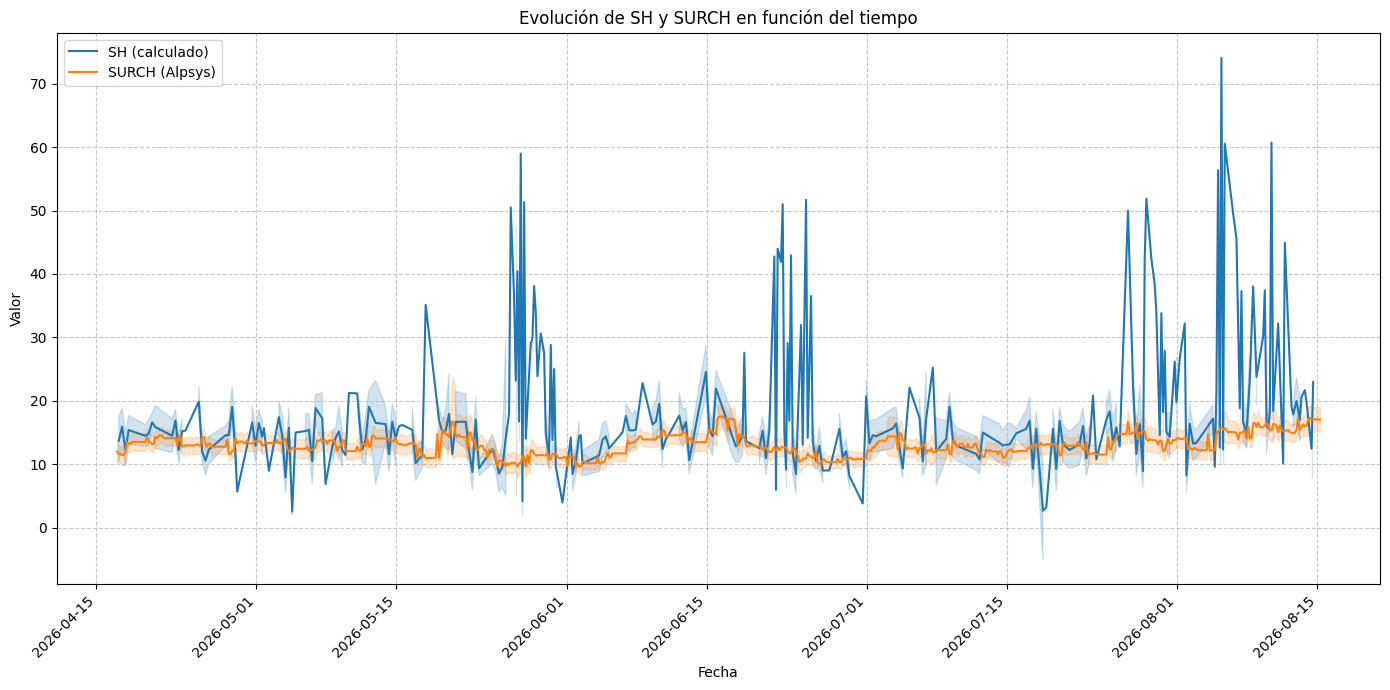

In [170]:
# Asegurarse de que 'SURCH' sea numérico, reemplazando comas por puntos y forzando errores a NaN
TABLERO['SURCH'] = pd.to_numeric(TABLERO['SURCH'].astype(str).str.replace(',', '.'), errors='coerce')

plt.figure(figsize=(14, 7))
sns.lineplot(data=TABLERO, x='Fecha', y='SH', label='SH (calculado)')
sns.lineplot(data=TABLERO, x='Fecha', y='SURCH', label='SURCH (Alpsys)')

plt.title('Evolución de SH y SURCH en función del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [171]:
# Re-ejecutar la celda que calcula 'SH' para asegurar que la columna exista en el DataFrame TABLERO

import numpy as np

# Ensure 'TB' is numeric just before calculation, as its type might have been altered by fillna('')
TABLERO['TB'] = pd.to_numeric(TABLERO['TB'].astype(str).str.replace(',', '.'), errors='coerce')

TABLERO['SH'] = np.nan
# The condition "cuando haya datos de ALF3 y CAF2" is implicitly handled by checking 'T Liq' notna
mask_sh = TABLERO['TB'].notna() & TABLERO['T Liq'].notna()
TABLERO.loc[mask_sh, 'SH'] = TABLERO.loc[mask_sh, 'TB'] - TABLERO.loc[mask_sh, 'T Liq']

display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,NaN,NaN,NaN
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,NaN,NaN,NaN
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,NaN,NaN,NaN
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,NaN,NaN,NaN
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,NaN,NaN,NaN


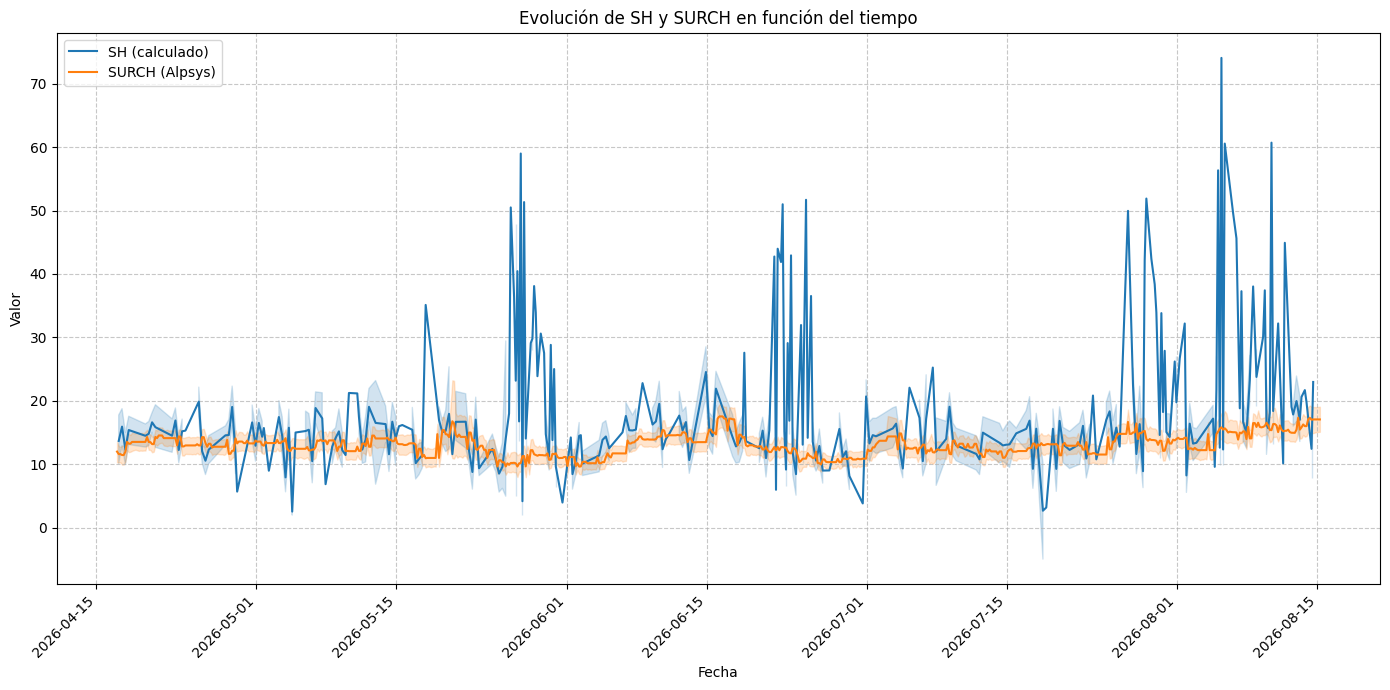

In [172]:
# Asegurarse de que 'SURCH' sea numérico, reemplazando comas por puntos y forzando errores a NaN
# Esta línea ya se ha ejecutado en una celda anterior, pero la incluyo para asegurar el flujo si se ejecuta esta celda de forma aislada.
TABLERO['SURCH'] = pd.to_numeric(TABLERO['SURCH'].astype(str).str.replace(',', '.'), errors='coerce')

plt.figure(figsize=(14, 7))
sns.lineplot(data=TABLERO, x='Fecha', y='SH', label='SH (calculado)')
sns.lineplot(data=TABLERO, x='Fecha', y='SURCH', label='SURCH (Alpsys)')

plt.title('Evolución de SH y SURCH en función del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

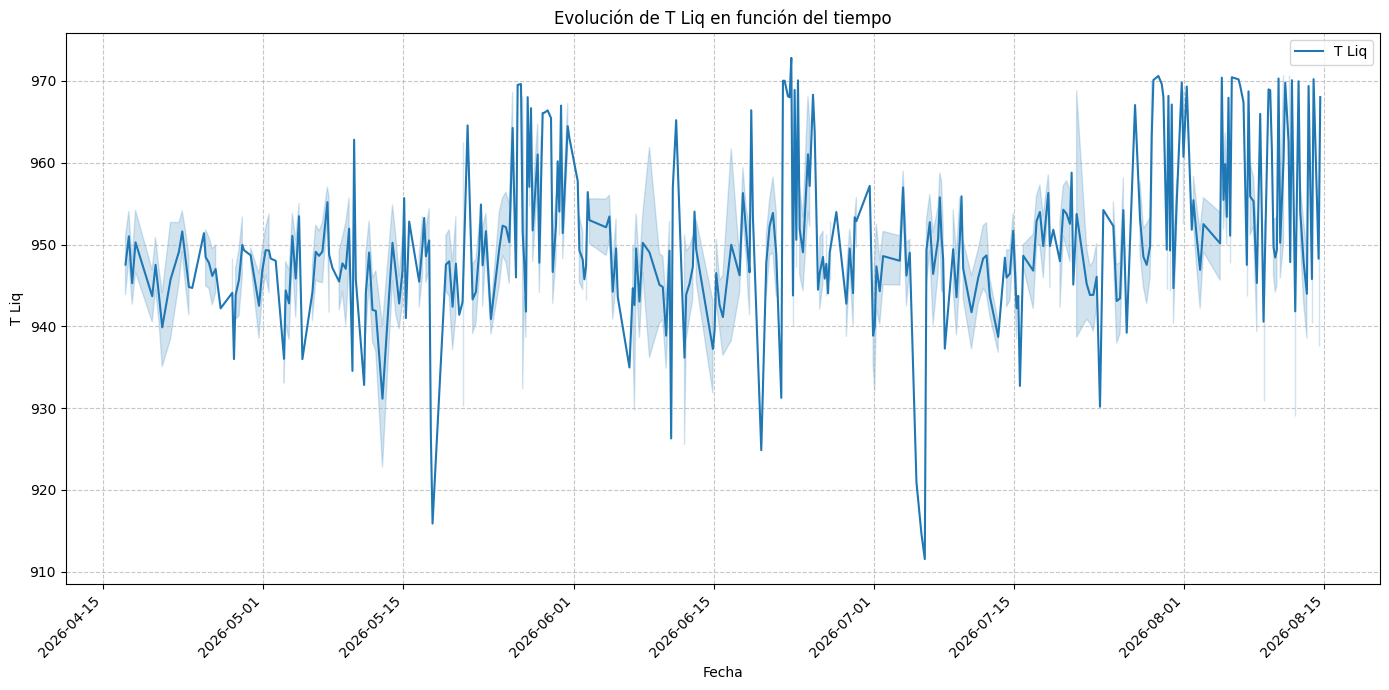

In [173]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=TABLERO, x='Fecha', y='T Liq', label='T Liq')

plt.title('Evolución de T Liq en función del tiempo')
plt.xlabel('Fecha')
plt.ylabel('T Liq')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [174]:
TABLERO['TB'] = pd.to_numeric(TABLERO['TB'].astype(str).str.replace(',', '.'), errors='coerce')

display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,NaN,NaN,NaN
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,NaN,NaN,NaN
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,NaN,NaN,NaN
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,NaN,NaN,NaN
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,NaN,NaN,NaN


In [175]:
TABLERO = TABLERO.fillna('')
display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,,,
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,,,
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,,,
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,,,
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,,,


In [176]:
# Crear la columna %Al2O3
TABLERO['%Al2O3'] = 3.5

display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,,,
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,,,
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,,,
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,,,
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,,"12,1",...,,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,,,


In [177]:
TABLERO['ALF3'] = pd.to_numeric(TABLERO['ALF3'].astype(str).str.replace(',', '.'), errors='coerce')
TABLERO['CaF2'] = pd.to_numeric(df['CAF2'].astype(str).str.replace(',', '.'), errors='coerce')

display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,NaN,,
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,NaN,,
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,NaN,,
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,NaN,,
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,NaN,,


### Calcular la Columna 'SH' =TB - T liquidus

Definición de T de liquidus

In [178]:
import numpy as np

# Ensure 'ALF3', 'CaF2', and '%Al2O3' columns are numeric.
# Handle comma decimals and coerce errors to NaN.
TABLERO['ALF3'] = pd.to_numeric(TABLERO['ALF3'].astype(str).str.replace(',', '.'), errors='coerce')
TABLERO['CaF2'] = pd.to_numeric(TABLERO['CaF2'].astype(str).str.replace(',', '.'), errors='coerce')
TABLERO['%Al2O3'] = pd.to_numeric(TABLERO['%Al2O3'].astype(str).str.replace(',', '.'), errors='coerce')

# Initialize 'T Liq' column with NaN (Not a Number)
TABLERO['T Liq'] = np.nan

# Create a boolean mask to identify rows where 'ALF3', 'CaF2', and '%Al2O3' have valid (non-NaN) data
mask = TABLERO['ALF3'].notna() & TABLERO['CaF2'].notna() & TABLERO['%Al2O3'].notna()

# Apply the formula only to the rows that satisfy the mask condition
# Use .loc to avoid SettingWithCopyWarning and ensure calculations are precise
if mask.any(): # Only proceed if there are rows that satisfy the condition
    _ALF3 = TABLERO.loc[mask, 'ALF3']
    _CaF2 = TABLERO.loc[mask, 'CaF2']
    _Al2O3 = TABLERO.loc[mask, '%Al2O3']

    # Calculate T Liq based on the provided formula
    T_Liq_values = (
        1011
        + 0.5 * _ALF3
        - 0.13 * (_ALF3**2.2)
        - 3.45 * _CaF2 / (1 + 0.0173 * _CaF2)
        + 0.124 * _CaF2 * _ALF3
        - 0.00542 * ((_CaF2 * _ALF3)**1.5)
        - 7.93 * _Al2O3 / (1 + 0.0936 * _Al2O3 - 0.0017 * (_Al2O3**2) - 0.0023 * _ALF3 * _Al2O3)
        - 8.9 * 0.3 / (1 + 0.0047 * 0.3 + 0.001 * (_ALF3**2))
        - 3.95 * 0.18
        - 3.95 * 0.2
    )

    # Assign the calculated values back to the 'T Liq' column for the masked rows
    TABLERO.loc[mask, 'T Liq'] = T_Liq_values

# Display the head of the DataFrame with the new 'T Liq' column
display(TABLERO.head())
# Display info to confirm data types, especially for 'T Liq', 'ALF3', and 'CaF2'
TABLERO.info()

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,NaN,NaN,
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,NaN,NaN,
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,NaN,NaN,
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,NaN,NaN,
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,NaN,NaN,


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51293 entries, 0 to 51292
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   N_FECHA_SMTU   51293 non-null  int64         
 1   FT_TURNO       51293 non-null  object        
 2   TU_SEMI_TURNO  51293 non-null  int64         
 3   C_SERIE        51293 non-null  object        
 4   CUBA           51293 non-null  int64         
 5   N_VIDA         51293 non-null  int64         
 6   X_MODELO       51293 non-null  object        
 7   POTSTATE       51293 non-null  int64         
 8   ALF3           3495 non-null   float64       
 9   ALF3C          51293 non-null  object        
 10  M_CUBA_MADRE   51293 non-null  object        
 11  IPS            51293 non-null  object        
 12  V_TFLUO        51293 non-null  object        
 13  V_ULT_CU       51293 non-null  object        
 14  V_ACD          51293 non-null  object        
 15  SMRWFC         5129

In [179]:
import numpy as np

# Ensure 'TB' is numeric just before calculation, as its type might have been altered by fillna('')
TABLERO['TB'] = pd.to_numeric(TABLERO['TB'].astype(str).str.replace(',', '.'), errors='coerce')

TABLERO['SH'] = np.nan
# The condition "cuando haya datos de ALF3 y CAF2" is implicitly handled by checking 'T Liq' notna
mask_sh = TABLERO['TB'].notna() & TABLERO['T Liq'].notna()
TABLERO.loc[mask_sh, 'SH'] = TABLERO.loc[mask_sh, 'TB'] - TABLERO.loc[mask_sh, 'T Liq']

display(TABLERO.head())

,N_FECHA_SMTU,FT_TURNO,TU_SEMI_TURNO,C_SERIE,CUBA,N_VIDA,X_MODELO,POTSTATE,ALF3,ALF3C,...,TB,SURCH,AGEBSQ_Ratio,POTAGE_Ratio,TURNO,Fecha,%Al2O3,CaF2,T Liq,SH
0,2026041711,17/4/2026 00:00,1,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,0417","2025,0417",06:00,2026-04-17 06:00:00,3.5,NaN,NaN,NaN
1,2026041712,17/4/2026 00:00,2,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,2083","2025,2083",10:00,2026-04-17 10:00:00,3.5,NaN,NaN,NaN
2,2026041723,17/4/2026 00:00,3,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,375","2025,375",14:00,2026-04-17 14:00:00,3.5,NaN,NaN,NaN
3,2026041724,17/4/2026 00:00,4,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,5417","2025,5417",18:00,2026-04-17 18:00:00,3.5,NaN,NaN,NaN
4,2026041735,17/4/2026 00:00,5,C,501,4,AP22.0,3,NaN,"12,1",...,NaN,10.0,"2025,7083","2025,7083",22:00,2026-04-17 22:00:00,3.5,NaN,NaN,NaN


In [180]:
# Display info to confirm data types, especially for 'SH', 'ALF3', and 'CaF2'
TABLERO.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51293 entries, 0 to 51292
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   N_FECHA_SMTU   51293 non-null  int64         
 1   FT_TURNO       51293 non-null  object        
 2   TU_SEMI_TURNO  51293 non-null  int64         
 3   C_SERIE        51293 non-null  object        
 4   CUBA           51293 non-null  int64         
 5   N_VIDA         51293 non-null  int64         
 6   X_MODELO       51293 non-null  object        
 7   POTSTATE       51293 non-null  int64         
 8   ALF3           3495 non-null   float64       
 9   ALF3C          51293 non-null  object        
 10  M_CUBA_MADRE   51293 non-null  object        
 11  IPS            51293 non-null  object        
 12  V_TFLUO        51293 non-null  object        
 13  V_ULT_CU       51293 non-null  object        
 14  V_ACD          51293 non-null  object        
 15  SMRWFC         5129

**Análisis**

Evolución de TB y T Liq en función del tiempo

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Importa librerias para graficar'

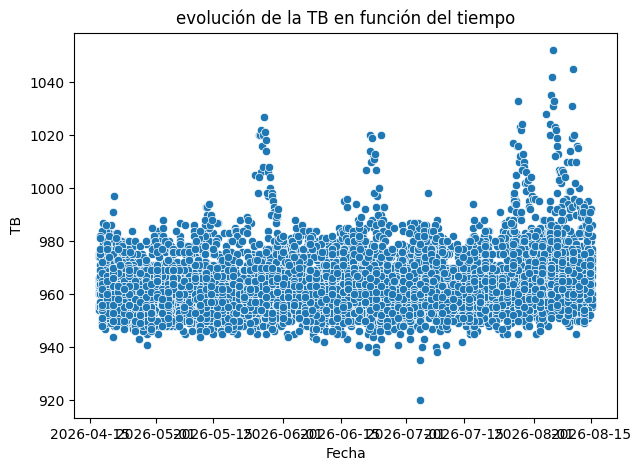

In [182]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Fecha", y="TB")
plt.title("evolución de la TB en función del tiempo")
plt.xlabel("Fecha")
plt.ylabel("TB")
plt.show()


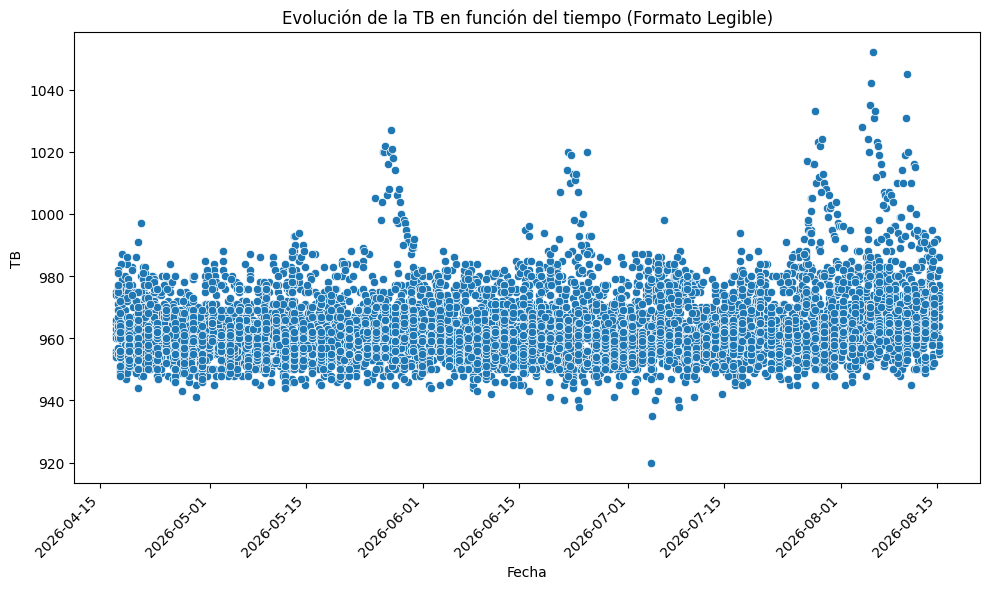

In [183]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=TABLERO, x="Fecha", y="TB")
plt.title("Evolución de la TB en función del tiempo (Formato Legible)")
plt.xlabel("Fecha")
plt.ylabel("TB")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [184]:
# Establecer 'Fecha' como índice para operaciones de series temporales
TABLERO_resampled = TABLERO.set_index('Fecha')

# Agrupar cada 5 días y calcular la media para 'TB' y 'T Liq'
TABLERO_5d = TABLERO_resampled[['TB', 'T Liq']].resample('5D').mean().reset_index()

# Mostrar las primeras filas del DataFrame remuestreado
display(TABLERO_5d.head())

,Fecha,TB,T Liq
0,2026-04-17,962.825000,946.203753
1,2026-04-22,961.965398,947.857066
2,2026-04-27,961.176471,946.431056
3,2026-05-02,961.556338,946.807731
4,2026-05-07,960.910653,946.813367


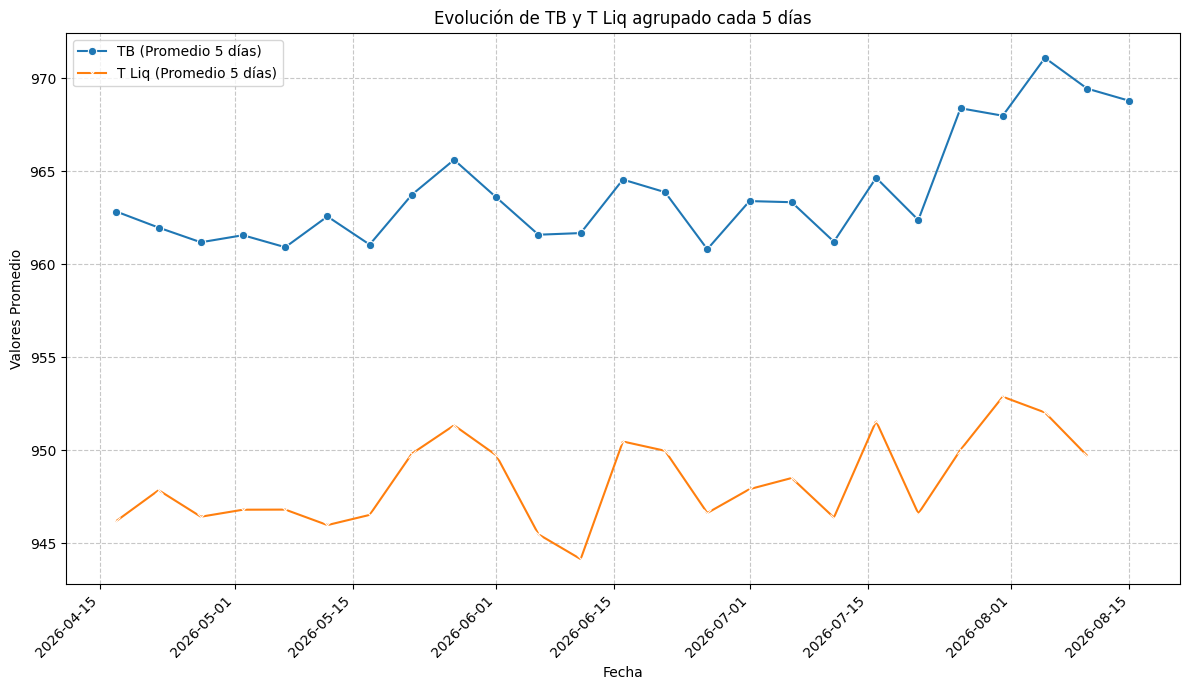

In [185]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=TABLERO_5d, x='Fecha', y='TB', label='TB (Promedio 5 días)', marker='o')
sns.lineplot(data=TABLERO_5d, x='Fecha', y='T Liq', label='T Liq (Promedio 5 días)', marker='x')
plt.title('Evolución de TB y T Liq agrupado cada 5 días')
plt.xlabel('Fecha')
plt.ylabel('Valores Promedio')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Histograma del SH

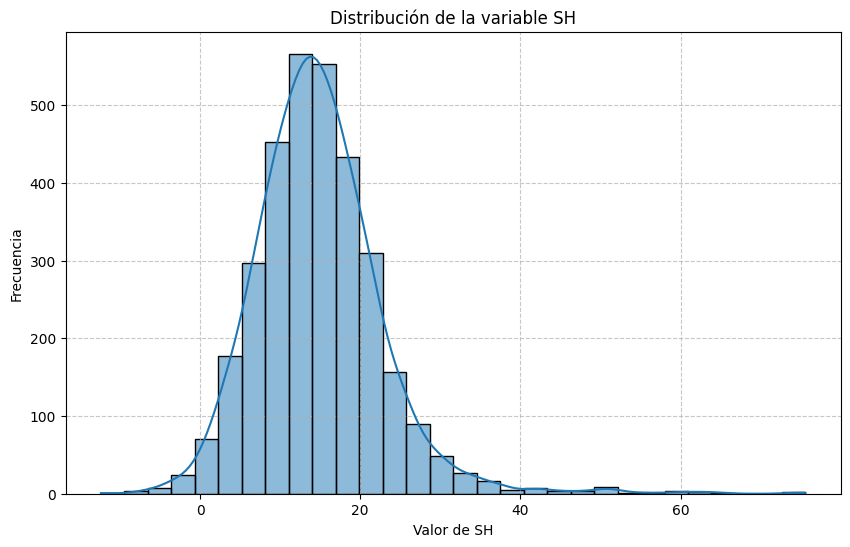

In [186]:
plt.figure(figsize=(10, 6))
sns.histplot(TABLERO['SH'].dropna(), bins=30, kde=True)
plt.title('Distribución de la variable SH')
plt.xlabel('Valor de SH')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [187]:
# Get current column names from TABLERO
current_tablero_cols = list(TABLERO.columns)

# Create a mapping for columns that were renamed in TABLERO
# This mapping goes from the TABLERO name to the original df name
renamed_cols_map_reverse = {
    'AGEBSQ_Ratio': 'AGEBSQ',
    'POTAGE_Ratio': 'POTAGE'
}

# Create a set of column names that are effectively in TABLERO,
# using their original names from df for comparison
effective_tablero_cols = set()
for col in current_tablero_cols:
    if col in renamed_cols_map_reverse:
        effective_tablero_cols.add(renamed_cols_map_reverse[col])
    else:
        effective_tablero_cols.add(col)

# Identify columns in df that are not yet in TABLERO (considering renames)
cols_to_add = [col for col in df.columns if col not in effective_tablero_cols]

# Add these columns to TABLERO
for col in cols_to_add:
    TABLERO[col] = df[col]

print(f"Se agregaron {len(cols_to_add)} columnas a TABLERO.")
display(TABLERO.info())

Se agregaron 37 columnas a TABLERO.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51293 entries, 0 to 51292
Data columns (total 66 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   N_FECHA_SMTU    51293 non-null  int64         
 1   FT_TURNO        51293 non-null  object        
 2   TU_SEMI_TURNO   51293 non-null  int64         
 3   C_SERIE         51293 non-null  object        
 4   CUBA            51293 non-null  int64         
 5   N_VIDA          51293 non-null  int64         
 6   X_MODELO        51293 non-null  object        
 7   POTSTATE        51293 non-null  int64         
 8   ALF3            3495 non-null   float64       
 9   ALF3C           51293 non-null  object        
 10  M_CUBA_MADRE    51293 non-null  object        
 11  IPS             51293 non-null  object        
 12  V_TFLUO         51293 non-null  object        
 13  V_ULT_CU        51293 non-null  object        
 14  V_ACD           51

None

In [188]:
file_name = 'TABLERO_sala5.csv'
TABLERO.to_csv(file_name, index=False)

print(f"El DataFrame ha sido exportado a '{file_name}'")

# Para descargar el archivo en Google Colab
from google.colab import files
files.download(file_name)

El DataFrame ha sido exportado a 'TABLERO_sala5.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>